### Problem Statement
1. Predict the ***delivery time*** for an order given some feature-list!

#### Feature-list:
- market_id : integer id for the market where the restaurant lies
- created_at : the timestamp at which the order was placed
- actual_delivery_time : the timestamp when the order was delivered
- store_primary_category : category for the restaurant
- order_protocol : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, pre booked, third part etc)
- total_items subtotal : final price of the order
- num_distinct_items : the number of distinct items in the order
- min_item_price : price of the cheapest item in the order
- max_item_price : price of the costliest item in order
- total_onshift_partners : number of delivery partners on duty at the time order was placed
- total_busy_partners : number of delivery partners attending to other tasks
- total_outstanding_orders : total number of orders to be fulfilled at the moment
- estimated_store_to_consumer_driving_duration : travel time taken from store to consumer address by the driver
#### Tasks - 
1. Define the problem statement, import data, data-structure analysis.   

2. Data preprocessing and feature engineering (Data Preparation - part 1)


3. Data viz (EDA) and cleaning (Data Preparation - part 2)


4. Training Random Forest (Modelling - part 1)


5. Training Neural Networks (Modelling - part 2)



## Task 1: Data I/O. 


a. install gdown and download data   
b. import pandas and load data; <font color='red'> do a briefer on pandas</font>.   
c. do df.info for general information on columns, no. of rows, dtypes etc.   
d. Inspect object datatype.   
e. do df.nunique() to identify categorical, numerical dataset.  
 

In [ ]:
!pip install --upgrade --no-cache-dir gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.6.6
    Uninstalling gdown-4.6.6:
      Successfully uninstalled gdown-4.6.6


In [ ]:
import gdown

In [ ]:
!gdown 1kkgBGldeswHBgVKEJiqqG7VZvqZNMc-5

Downloading...
From: https://drive.google.com/uc?id=1kkgBGldeswHBgVKEJiqqG7VZvqZNMc-5
To: /content/data_2.csv
100% 15.7M/15.7M [00:00<00:00, 142MB/s]


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('data_2.csv')
df

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175772,1.0,2015-02-17 00:19:41,2015-02-17 01:02:41,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0
175773,1.0,2015-02-13 00:01:59,2015-02-13 01:03:59,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0
175774,1.0,2015-01-24 04:46:08,2015-01-24 05:32:08,28,4.0,5,1836,3,300,399,39.0,41.0,40.0,795.0
175775,1.0,2015-02-01 18:18:15,2015-02-01 19:03:15,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0


### Refresher Pandas:

<img src='https://images2017.cnblogs.com/blog/709432/201708/709432-20170830192031421-1701706326.jpg' />

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [ ]:
df["created_at"][0], type(df["created_at"][0])

('2015-02-06 22:24:17', str)

In [ ]:
df.nunique()

market_id                                          6
store_primary_category                            73
order_protocol                                     7
total_items                                       54
subtotal                                        8182
num_distinct_items                                20
min_item_price                                  2251
max_item_price                                  2585
total_onshift_dashers                            172
total_busy_dashers                               158
total_outstanding_orders                         281
estimated_store_to_consumer_driving_duration    1318
time_taken_mins                                   74
hour                                              19
day                                                7
dtype: int64

## Task 2: Data Preprocessing (Data-preparation part 1)

0. [Zooming out] Acc. to problem given, do we have all the required things (no!), even before visualizing data, what can we say or do about the data itself? 

1. Data cleaning  
    a. <font color='red'> Deduplication </font>, talk about "inplace" argument
2. Null value handling   
    a. df.dropna() removes only "NaN" or None (missing) values
3. Creating the target column(time taken for delivery) from order timestamp and delivery timestamp.  
    a. pd.to_datetime, coz when you import csv files the datetime is imported as object(str) datatype, rather than datetime dataype; needs to do this!   
    b. calculate duration (pd.to_timedelta) and introduce pd.Timedelta().   
    c. convert it to float (also convert to mins).   
4. Getting hour and day of the week.   
    a. use datetime object to get both features   
    b. Additionally drop all unused columns related to above transformation
5. Encoding categorical column.  

In [ ]:
# drop duplicates
df.drop_duplicates()
len(df), len(df.drop_duplicates())

(175777, 175777)

In [ ]:
# dropna or fillna or dropnull or fillnull
# calcualate total "na" items
df.isna().sum()
df.dropna(inplace=True) #df.fillna(0)

Create target col
1. Datatype conversion (pd.to_datetime)
2. calculate duration (pd.to_timedelta)
3. convert it to float (also convert to mins)
4. introduce pd.Timedelta()

In [ ]:
df['created_at']= pd.to_datetime(df['created_at'])
df['actual_delivery_time']= pd.to_datetime(df['actual_delivery_time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  int64         
 8   min_item_price                                175777 n

In [ ]:
df['time_taken']=df['actual_delivery_time']-df['created_at']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype          
---  ------                                        --------------   -----          
 0   market_id                                     175777 non-null  float64        
 1   created_at                                    175777 non-null  datetime64[ns] 
 2   actual_delivery_time                          175777 non-null  datetime64[ns] 
 3   store_primary_category                        175777 non-null  int64          
 4   order_protocol                                175777 non-null  float64        
 5   total_items                                   175777 non-null  int64          
 6   subtotal                                      175777 non-null  int64          
 7   num_distinct_items                            175777 non-null  int64          
 8   min_item_price                              

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype          
---  ------                                        --------------   -----          
 0   market_id                                     175777 non-null  float64        
 1   created_at                                    175777 non-null  datetime64[ns] 
 2   actual_delivery_time                          175777 non-null  datetime64[ns] 
 3   store_primary_category                        175777 non-null  int64          
 4   order_protocol                                175777 non-null  float64        
 5   total_items                                   175777 non-null  int64          
 6   subtotal                                      175777 non-null  int64          
 7   num_distinct_items                            175777 non-null  int64          
 8   min_item_price                              

In [ ]:
df['time_taken_mins']=pd.to_timedelta(df['time_taken'])/pd.Timedelta('1m')
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,time_taken,time_taken_mins
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,0 days 00:47:00,47.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,0 days 00:44:00,44.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0 days 00:55:00,55.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,0 days 00:59:00,59.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,0 days 00:46:00,46.0


In [15]:
#extract hour and day separately
df['hour']=df['created_at'].dt.hour
df['day']=df['created_at'].dt.dayofweek
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,time_taken,time_taken_mins,hour,day
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,0 days 00:47:00,47.0,22,4
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,0 days 00:44:00,44.0,21,1
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,0 days 00:55:00,55.0,0,0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,0 days 00:59:00,59.0,3,3
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,0 days 00:46:00,46.0,2,1


In [16]:
# drop unusued columns (redundant datetime columns)
df.drop(['time_taken','created_at','actual_delivery_time'],axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   store_primary_category                        175777 non-null  int64  
 2   order_protocol                                175777 non-null  float64
 3   total_items                                   175777 non-null  int64  
 4   subtotal                                      175777 non-null  int64  
 5   num_distinct_items                            175777 non-null  int64  
 6   min_item_price                                175777 non-null  int64  
 7   max_item_price                                175777 non-null  int64  
 8   total_onshift_dashers                         175777 non-null  float64
 9   total_busy_dashers                            17

In [17]:
# convert categoricol to integers (label-encoding) For eg:
df['store_primary_category'] = df['store_primary_category'].astype('category').cat.codes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   store_primary_category                        175777 non-null  int8   
 2   order_protocol                                175777 non-null  float64
 3   total_items                                   175777 non-null  int64  
 4   subtotal                                      175777 non-null  int64  
 5   num_distinct_items                            175777 non-null  int64  
 6   min_item_price                                175777 non-null  int64  
 7   max_item_price                                175777 non-null  int64  
 8   total_onshift_dashers                         175777 non-null  float64
 9   total_busy_dashers                            17

## Task 3: Data Viz and cleaning (Data-preparation part 2)

0. **[Zooming out]** We have now some sense of what the features are, but still there are questions to answer like, are all features important, which features can be most important etc. Create intuitions:   
1. Data viz - Intuition to code Correlation plot -   
    a. get correlation coefficient using df.corr()
    b. plot it using sns.heatmap
2. Check for outliers   
    a. Scatterplots.  
3. Remove outliers.  
    a. Local Outlier Detection - awesome technique which takes care of both the local densities and global densities for identifying the outliers. How?   
        i. first calculate local density scores (using k-nn calculate the avg distance of the sample to its neighbours). Higher the number, more the chance for it to be an outlier.   
        ii. normalize it with the densities of the neighbours too, this gives us normalized score on which we can apply the threshold globally to get outliers.   
    b. Train outlier for all features at once in high dimensional space.       
    c. Drop those rows which have outliers, drop the "outlier" column in the end.   
4. Compare Plots

In [18]:
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})

<Axes: >

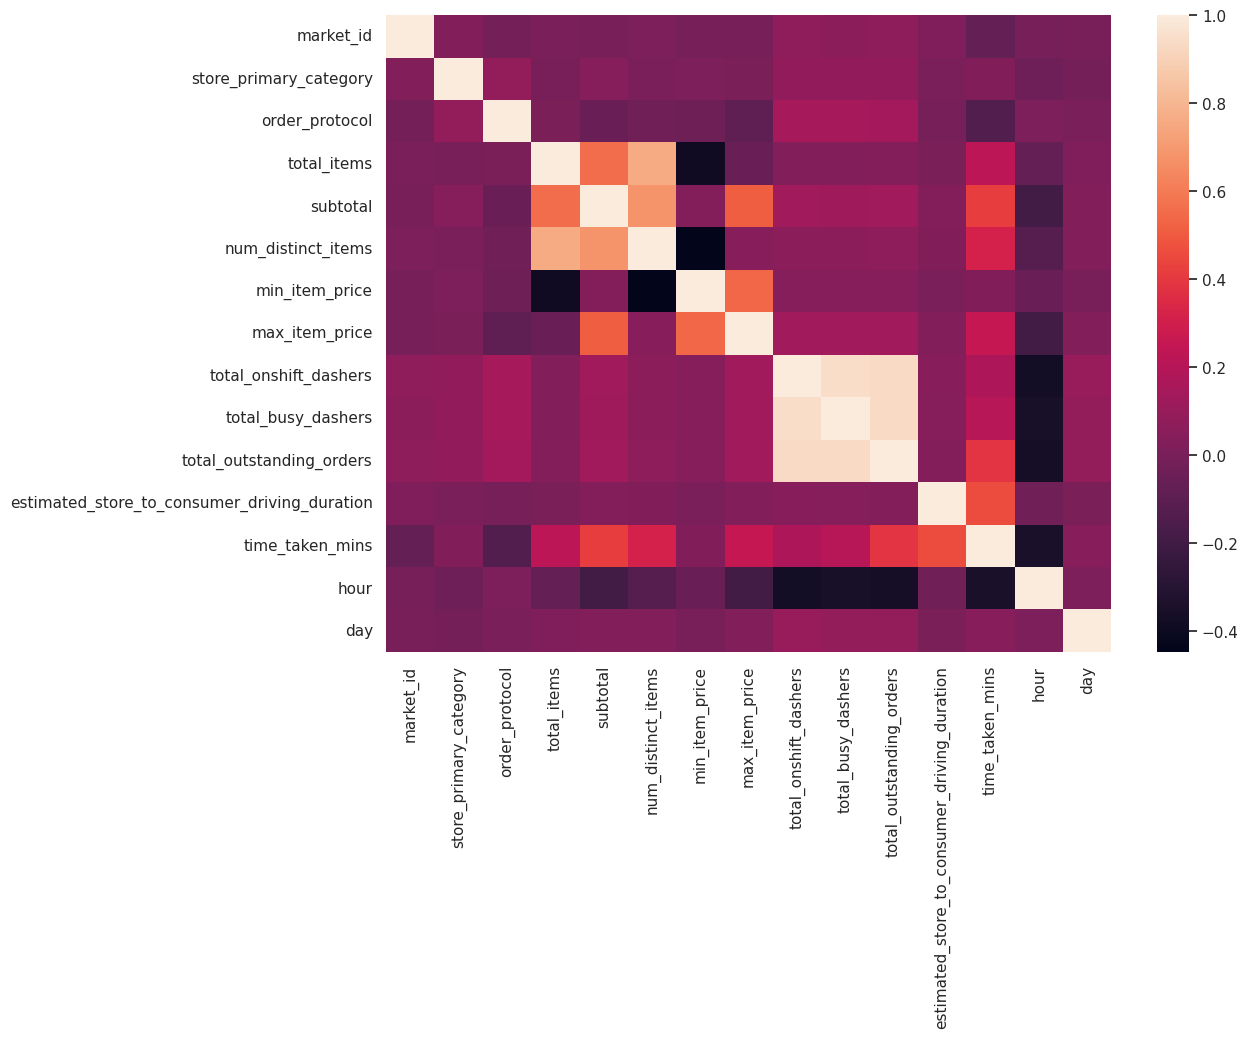

In [19]:
# 1. Data viz (correlation plot)
sns.heatmap(df.corr())

<Axes: xlabel='time_taken_mins', ylabel='subtotal'>

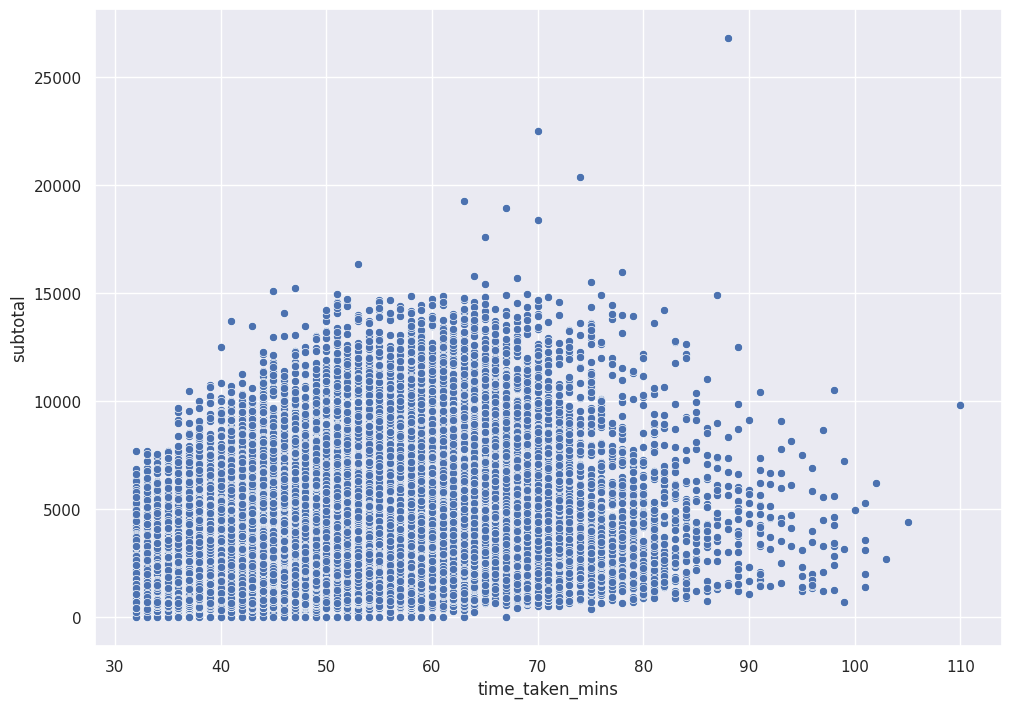

In [20]:
# 2. Check for outliers

sns.scatterplot(x='time_taken_mins', y='subtotal', data=df)

Remove outliers

1. Test on the above two columns
2. plot it again
3. repeat globally for all features
4. drop df_anamoly_score column

In [22]:
df['lof_anomaly_score']==-1

0         1
1         1
2         1
3         1
4         1
         ..
175772    1
175773    1
175774    1
175775    1
175776    1
Name: lof_anomaly_score, Length: 175777, dtype: int64

In [26]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
model = LocalOutlierFactor()

df['lof_anomaly_score'] = model.fit_predict(df[['subtotal', 'time_taken_mins']])
# df['lof_anomaly_score'] = model.fit_predict(df)

In [24]:
df

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,time_taken_mins,hour,day
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0,0,0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0,3,3
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175772,1.0,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0,43.0,0,1
175773,1.0,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0,62.0,0,4
175774,1.0,28,4.0,5,1836,3,300,399,39.0,41.0,40.0,795.0,46.0,4,5
175775,1.0,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0,45.0,18,6


number of outliers :  (12113, 12113)


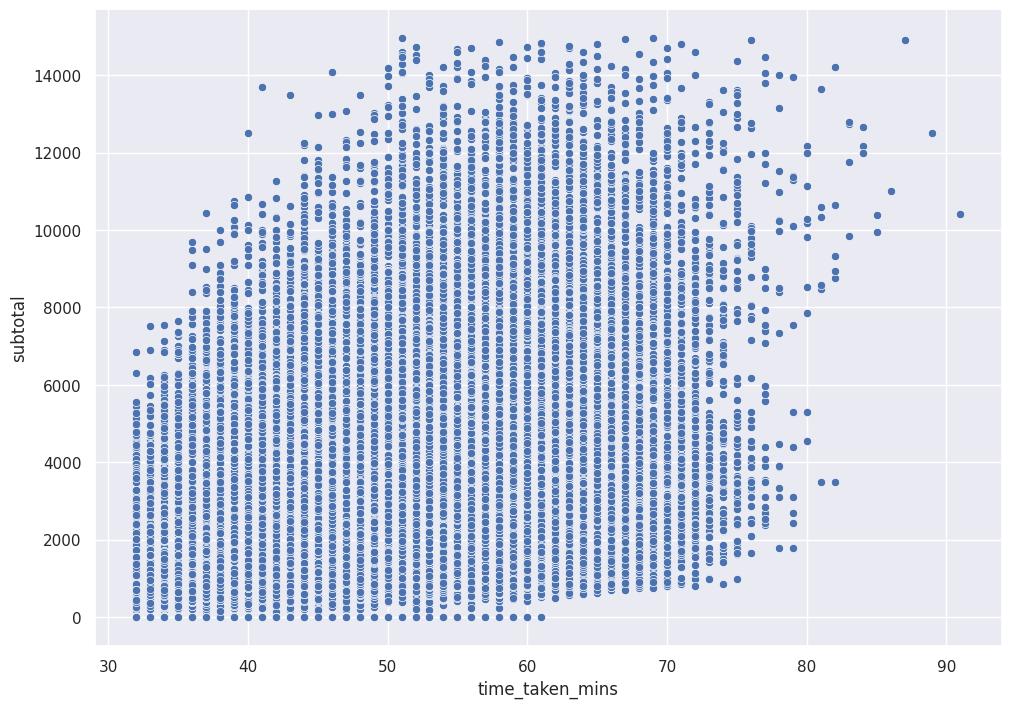

In [27]:
print("number of outliers : ",(len(df[df['lof_anomaly_score'] == -1]), (df['lof_anomaly_score'] == -1).sum()))
df_1 = df[df['lof_anomaly_score'] == 1]

sns.scatterplot(x='time_taken_mins', y='subtotal', data=df_1)

# drop anomaly column
df.drop(['lof_anomaly_score'],axis=1,inplace=True)

number of outliers :  (831, 831)


<ipython-input-28-05b7b2d16365>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['lof_anomaly_score'],axis=1,inplace=True)


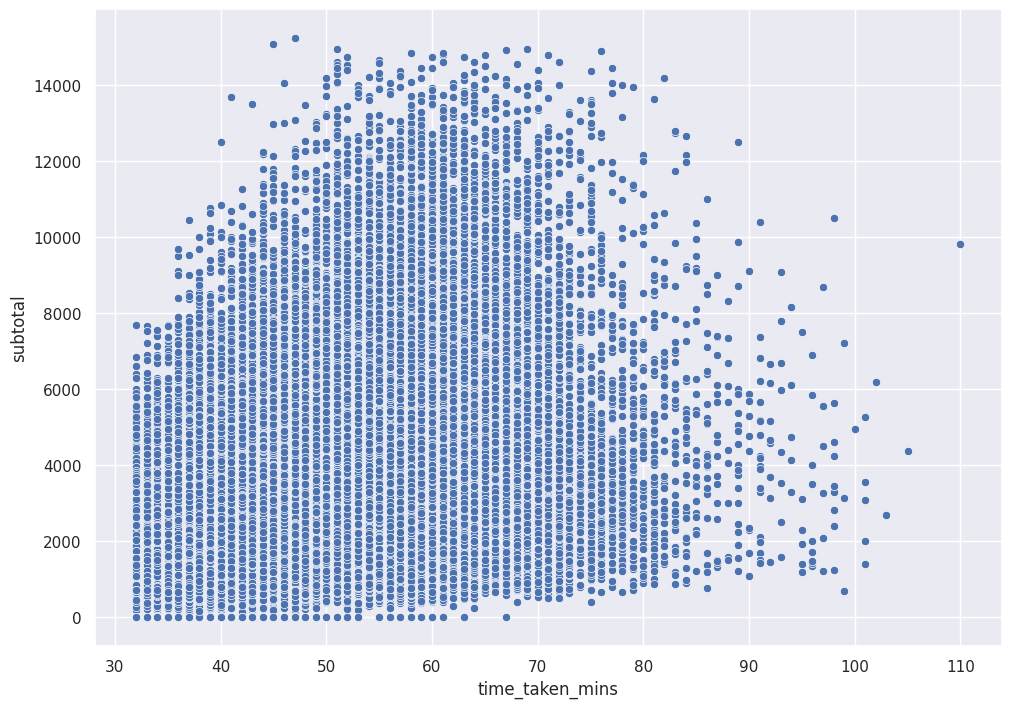

In [28]:
# Repeat globally
df['lof_anomaly_score'] = model.fit_predict(df)
print("number of outliers : ",(len(df[df['lof_anomaly_score'] == -1]), (df['lof_anomaly_score'] == -1).sum()))
df = df[df['lof_anomaly_score'] == 1]

sns.scatterplot(x='time_taken_mins', y='subtotal', data=df)

# drop anomaly column
df.drop(['lof_anomaly_score'],axis=1,inplace=True)

Compare plots

<Axes: xlabel='day', ylabel='count'>

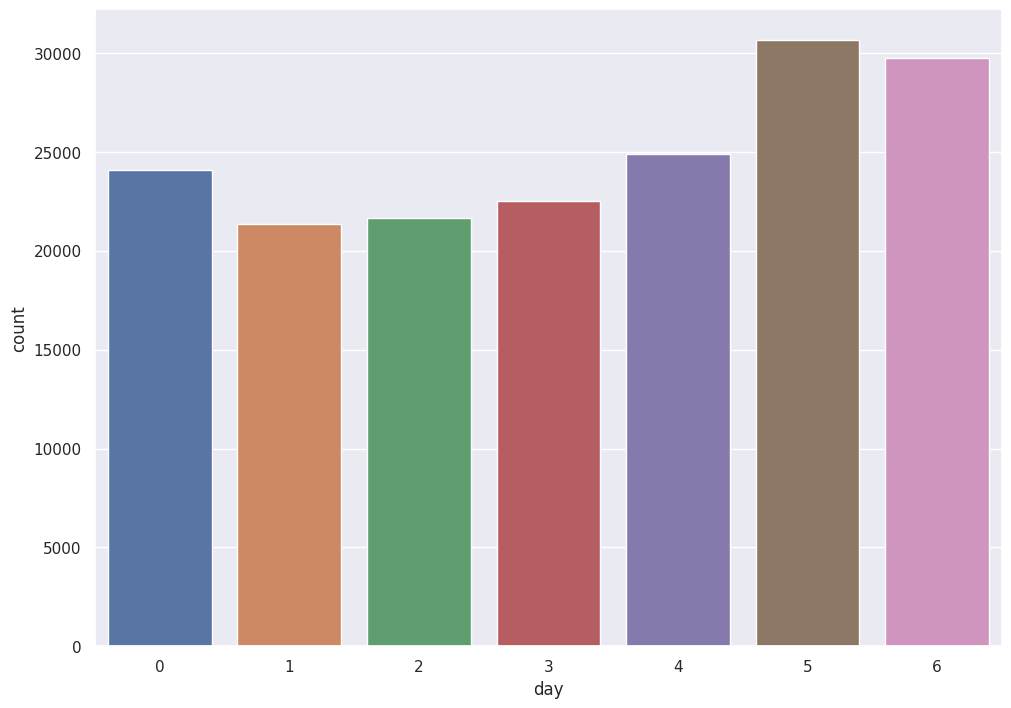

In [ ]:
sns.countplot(data=df, x="day")

<Axes: xlabel='hour', ylabel='count'>

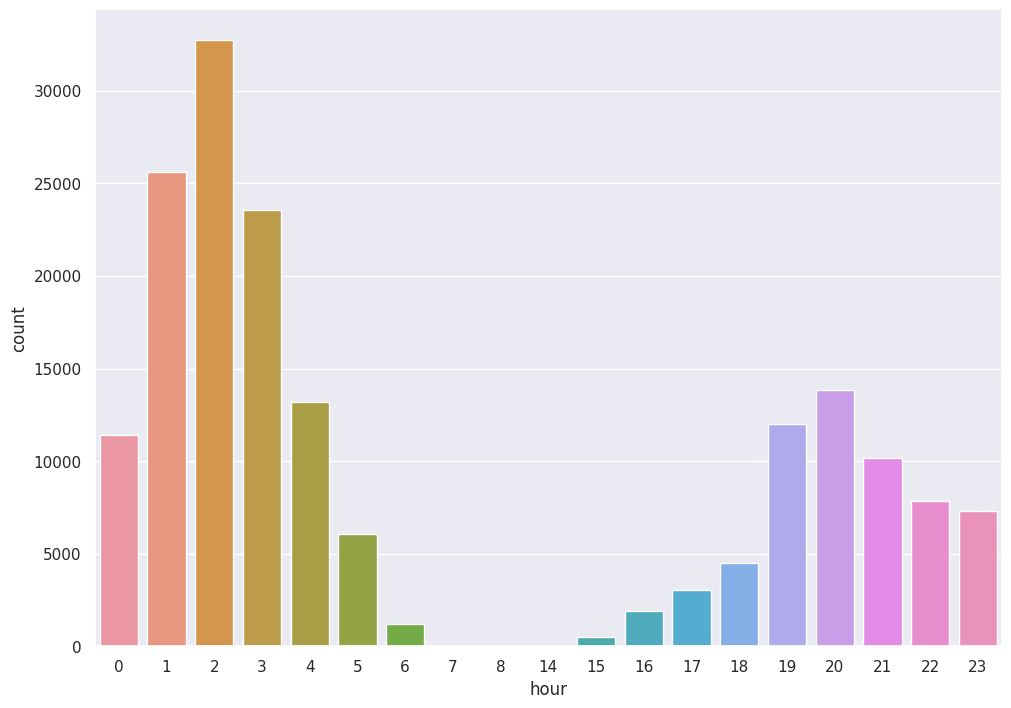

In [ ]:
sns.countplot(data=df, x="hour")

<Axes: xlabel='hour', ylabel='time_taken_mins'>

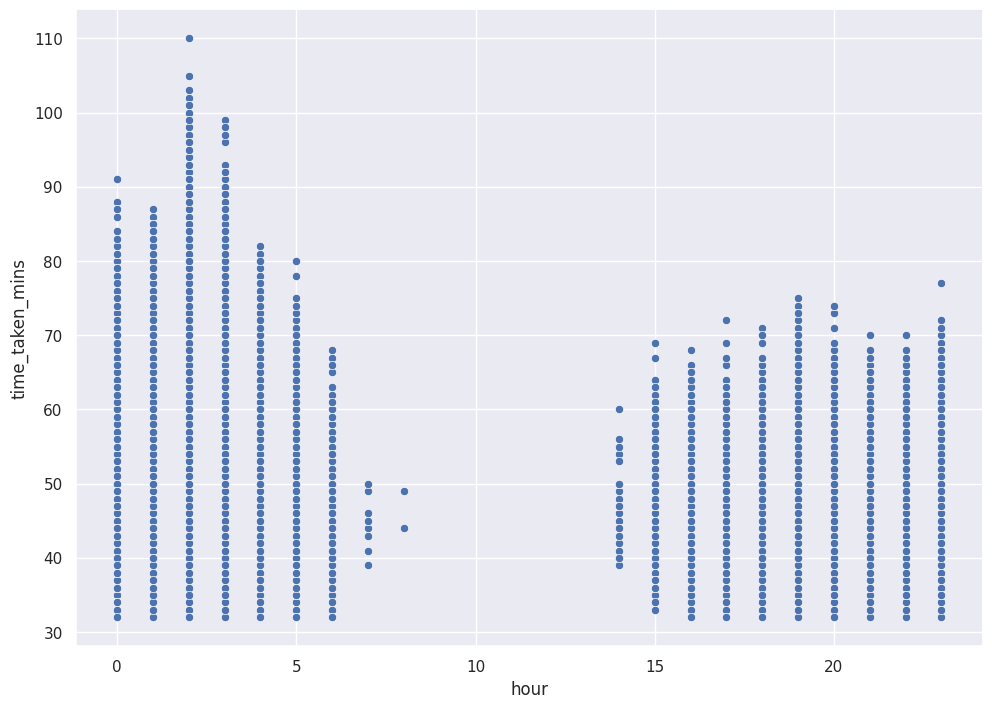

In [ ]:
sns.scatterplot(data=df, x="hour", y="time_taken_mins")

<Axes: xlabel='market_id', ylabel='count'>

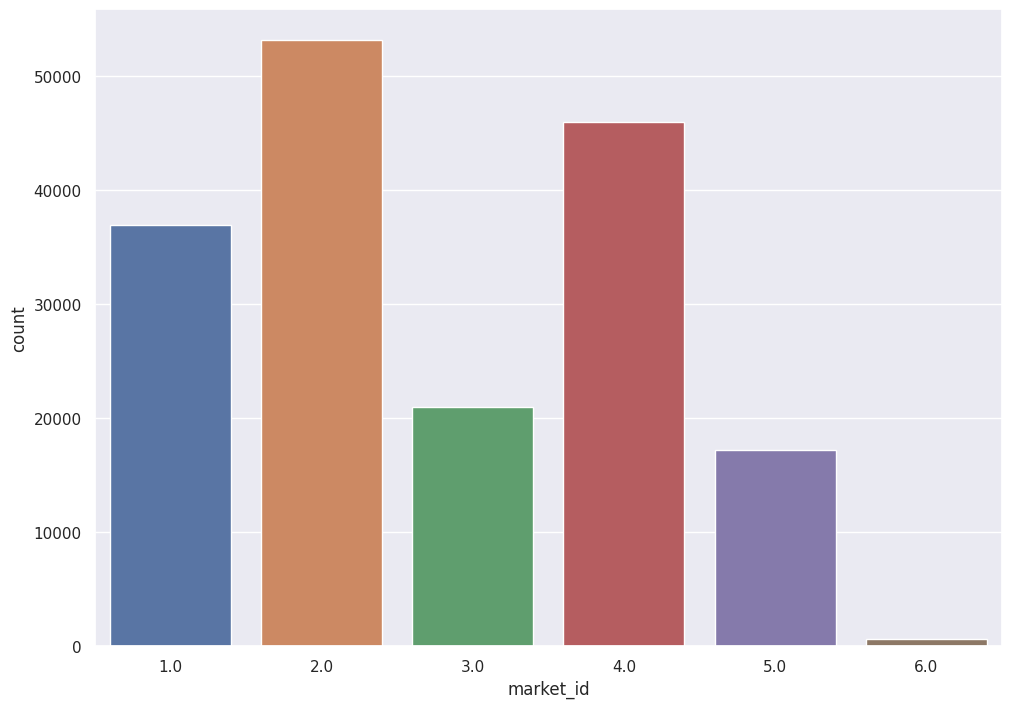

In [ ]:
sns.countplot(data=df, x="market_id")

<Axes: xlabel='market_id', ylabel='time_taken_mins'>

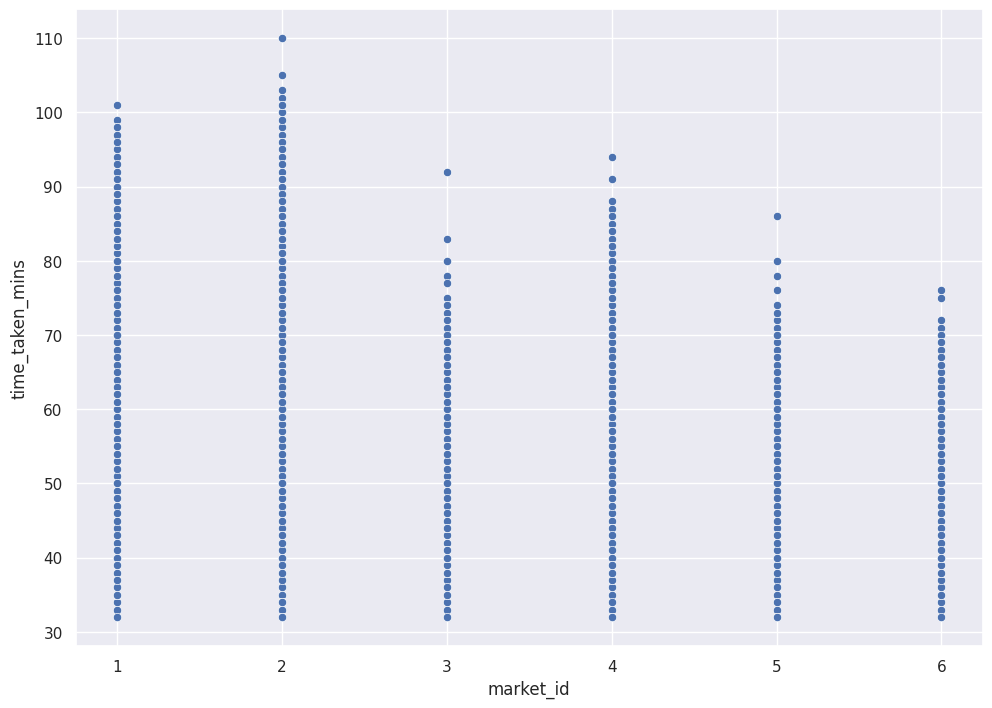

In [ ]:
sns.scatterplot(data=df, x="market_id", y="time_taken_mins")

## Task 4: Training Random Forest (Modelling - part 1)

0. Zooming out
1. Data Split
2. Model Random Forest
3. Evaluation metrics and its interpretation
4. Feature importance

In [ ]:
from sklearn.model_selection import train_test_split
# Data_split

y=df['time_taken_mins']
x = df.drop(['time_taken_mins'], axis=1)
df.drop(['time_taken_mins'], axis=1,inplace=True)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,  random_state=42)

<ipython-input-116-4dcf2e61bfad>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['time_taken_mins'], axis=1,inplace=True)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Model Random Forest
regressor = RandomForestRegressor()
 
regressor.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

# Prediction
prediction = regressor.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, prediction)
rmse = mse**.5
print("mse : ", mse)
print("rmse : ",rmse)

mae = mean_absolute_error(y_test, prediction)
print('mae:' ,mae)

r2_score = r2_score(y_test, prediction)
print('r_squared:' ,r2_score)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


mse :  108.95123329808517
rmse :  10.437970746178836
mae: 8.28641240354387
r_squared: -0.2662800031309325


In [ ]:
import numpy as np
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [ ]:
print("mape : ",MAPE(y_test, prediction))

mape :  0.17693949373999276


Text(0.5, 0, 'Random Forest Feature Importance')

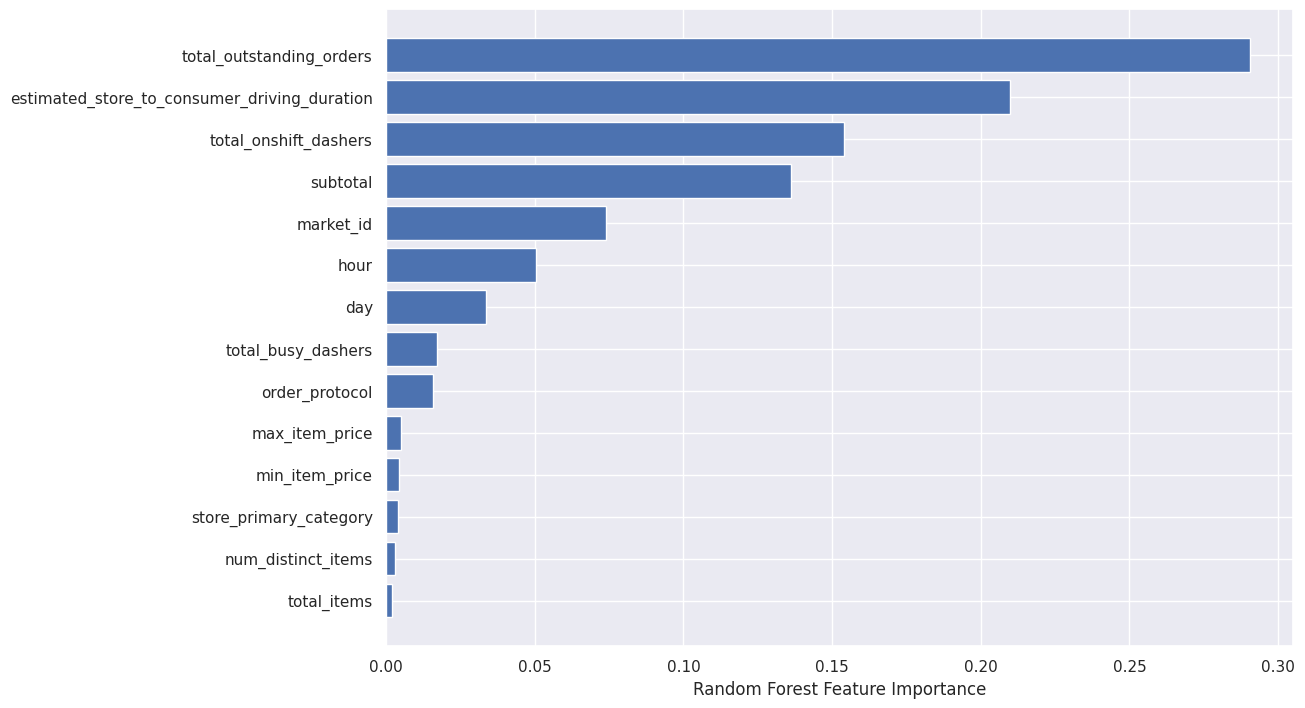

In [ ]:
# Feature importance

sorted_idx = regressor.feature_importances_.argsort()
plt.barh(df.columns[sorted_idx], regressor.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

## Task 5. Training Neural Networks (Modelling - part 2)

1. scaling of features
2. define model
3. model.fit
4. plots
5. model.predict
5. evaluate

In [ ]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()
x_scaled = scaler.fit_transform(x)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2,  random_state=42)

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(14,  kernel_initializer='normal', activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='linear'))

In [ ]:
from tensorflow.keras.optimizers import Adam
adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse','mae'])
history=model.fit(X_train, y_train, epochs=30, batch_size=512, verbose=1, validation_split=0.2)

Epoch 1/30
219/219 [==============================] - 20s 85ms/step - loss: 73.3600 - mse: 73.3600 - mae: 5.0032 - val_loss: 3.6542 - val_mse: 3.6542 - val_mae: 1.5080
Epoch 2/30
219/219 [==============================] - 15s 70ms/step - loss: 2.3519 - mse: 2.3519 - mae: 1.1638 - val_loss: 1.3723 - val_mse: 1.3723 - val_mae: 0.8706
Epoch 3/30
219/219 [==============================] - 17s 78ms/step - loss: 1.8404 - mse: 1.8404 - mae: 1.0411 - val_loss: 1.3489 - val_mse: 1.3489 - val_mae: 0.9028
Epoch 4/30
219/219 [==============================] - 15s 68ms/step - loss: 1.6447 - mse: 1.6447 - mae: 0.9913 - val_loss: 1.8211 - val_mse: 1.8211 - val_mae: 1.1846
Epoch 5/30
219/219 [==============================] - 15s 70ms/step - loss: 1.3345 - mse: 1.3345 - mae: 0.9302 - val_loss: 0.5769 - val_mse: 0.5769 - val_mae: 0.5981
Epoch 6/30
219/219 [==============================] - 15s 70ms/step - loss: 1.4211 - mse: 1.4211 - mae: 0.8617 - val_loss: 2.0948 - val_mse: 2.0948 - val_mae: 1.3418
Ep

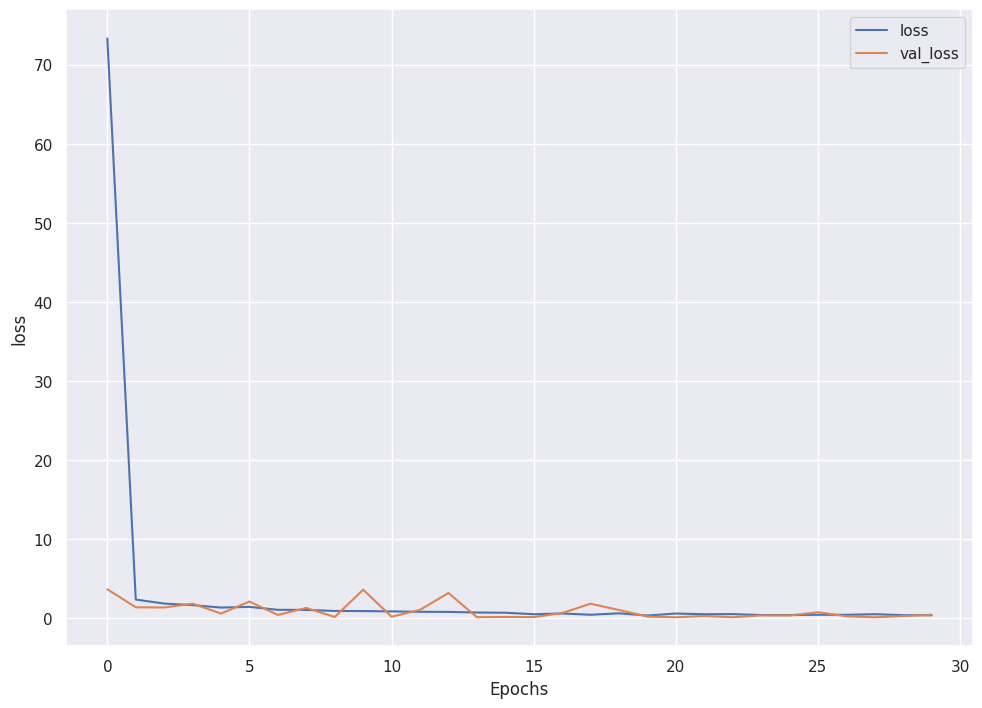

In [ ]:
def plot_history(history, key):
  plt.plot(history.history[key])
  plt.plot(history.history['val_'+key])
  plt.xlabel("Epochs")
  plt.ylabel(key)
  plt.legend([key, 'val_'+key])
  plt.show()
# Plot the history
plot_history(history, 'loss')

In [ ]:
# Prediction
prediction = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, prediction)
rmse = mse**.5
print("mse : ", mse)
print("rmse : ",rmse)

mae = mean_absolute_error(y_test, prediction)
print('mae:' ,mae)

1094/1094 [==============================] - 4s 4ms/step
mse :  0.42126892691178
rmse :  0.6490523298716213
mae: 0.5574296711989558


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as MAPE
print("mape : ",MAPE(y_test, prediction))

mape :  0.01218405333209551
